In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

np.random.seed(42)

data = {
    "customer_id": np.arange(1,201),
    "age": np.random.randint(18,65,200),
    "income": np.random.randint(30000,120000,200),
    "spending_score": np.random.randint(1,100,200),
    "gender": np.random.choice(["Male","Female"],200)
}

df = pd.DataFrame(data)
df.to_csv("data.csv")

In [3]:
#Basic Data Analysis
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customer_id     200 non-null    int64
 1   age             200 non-null    int64
 2   income          200 non-null    int64
 3   spending_score  200 non-null    int64
 4   gender          200 non-null    str  
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [5]:
df.head()
df.describe()

,customer_id,age,income,spending_score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,41.570000,73715.405000,50.100000
std,57.879185,13.715527,26539.827227,29.767609
min,1.000000,18.000000,30301.000000,1.000000
25%,50.750000,30.000000,50656.500000,23.000000
50%,100.500000,42.000000,75619.500000,51.500000
75%,150.250000,54.000000,96137.500000,75.250000
max,200.000000,64.000000,119912.000000,99.000000


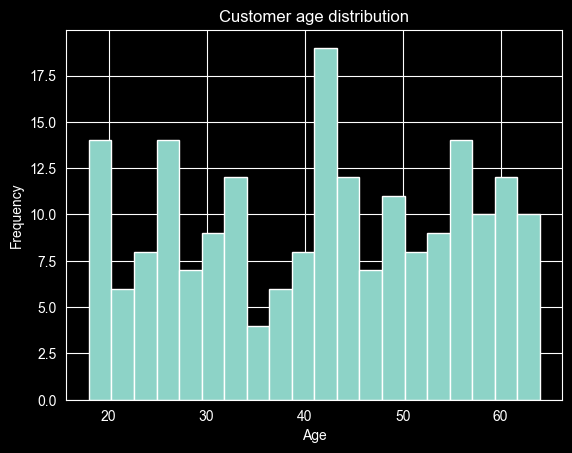

In [6]:
#Age Distribution (Histogram)

plt.hist(df["age"],bins=20)
plt.title("Customer age distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

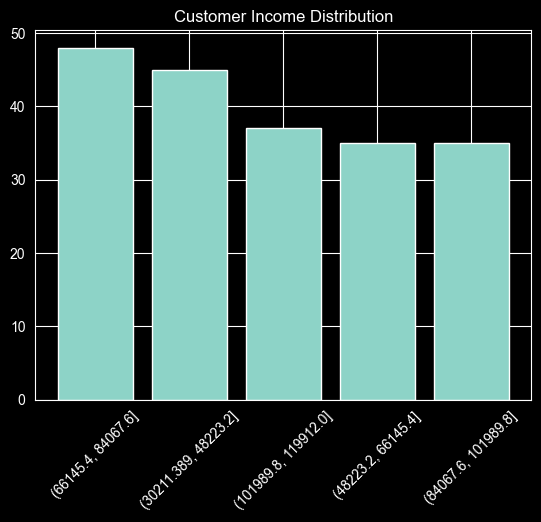

In [7]:
#Income Distribution (Bar Chart)
income_groups = pd.cut(df["income"], bins=5).value_counts()

plt.bar(income_groups.index.astype(str), income_groups.values)

plt.xticks(rotation=45)

plt.title("Customer Income Distribution")

plt.show()

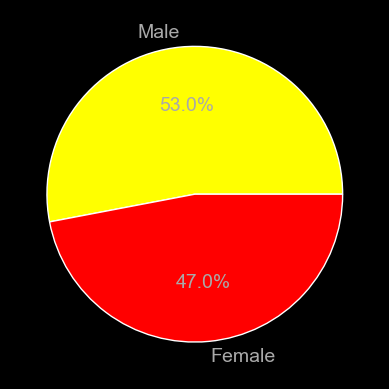

In [17]:
#Gender Distribution (Pie Chart)
plt.pie(df["gender"].value_counts(),colors=["yellow","red"], labels=df["gender"].value_counts().index,autopct="%1.1f%%",
        textprops={
            "color":"darkgrey",
            "fontsize":14
        })
plt.show()

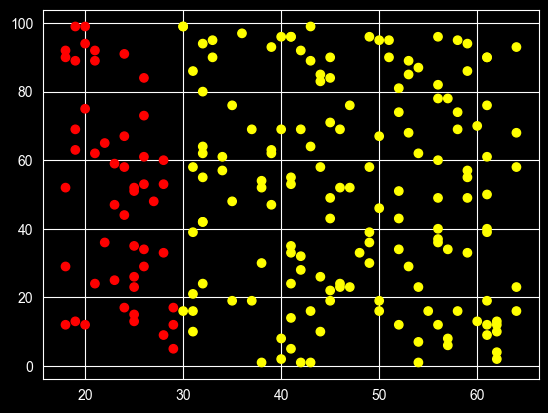

In [23]:
#Age vs Spending Score (Scatter Plot)
color=["red" if age<30 else "yellow" for age in df["age"]]
plt.scatter(df["age"],df["spending_score"],color=color)
plt.show()

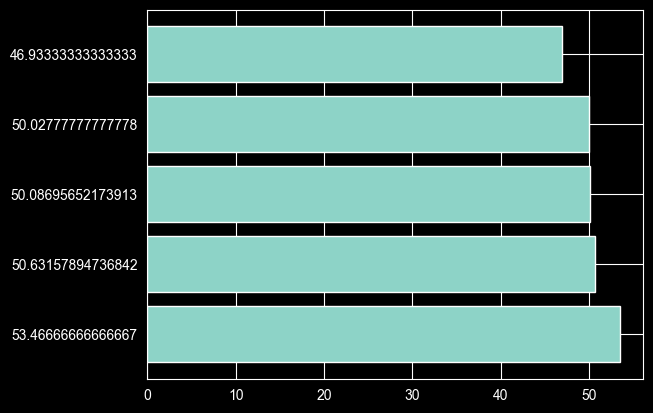

In [26]:
#Average Spending by Age Group (Barh)
age_groups=pd.cut(df["age"],bins=[18,25,35,45,55,65])
avg_spending=df.groupby(age_groups)["spending_score"].mean()
plt.barh(avg_spending.astype(str),avg_spending.values)
plt.show()

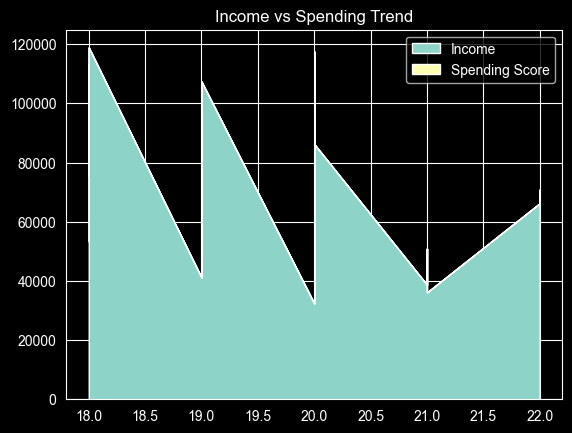

In [28]:
sample = df.sort_values("age").head(20)

plt.stackplot(
    sample["age"],
    sample["income"],
    sample["spending_score"],
    labels=["Income","Spending Score"]
)

plt.legend()

plt.title("Income vs Spending Trend")

plt.show()

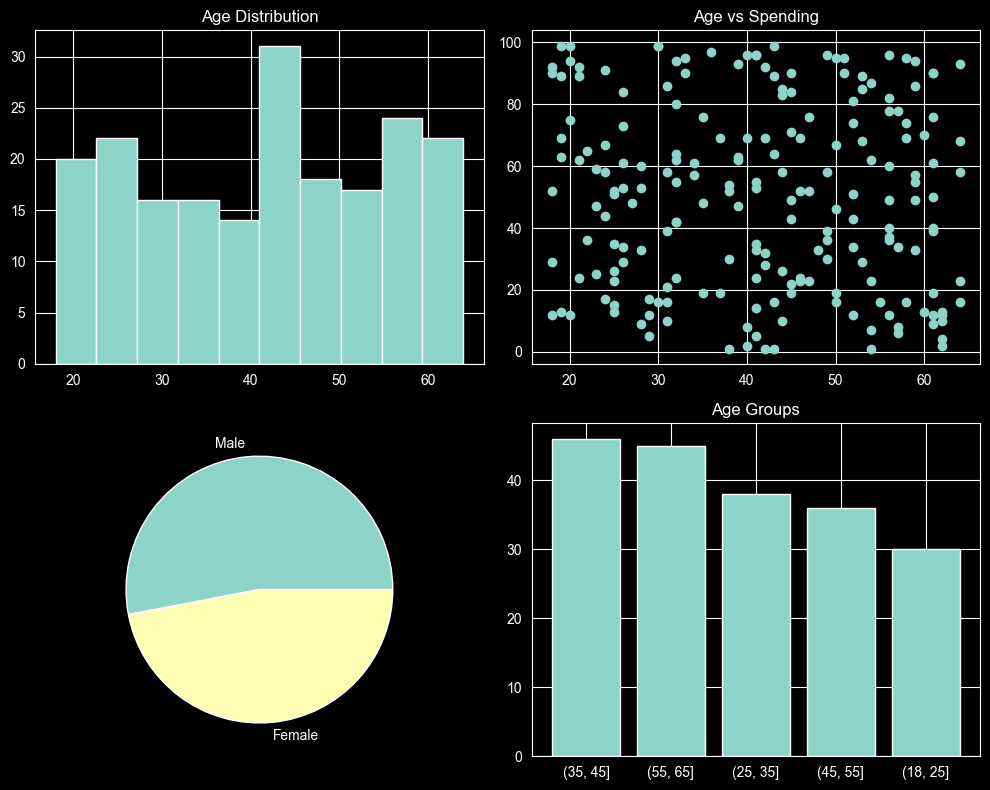

In [30]:
fig,axs = plt.subplots(2,2,figsize=(10,8))
gender_counts = df["gender"].value_counts()
axs[0,0].hist(df["age"], bins=10)
axs[0,0].set_title("Age Distribution")

axs[0,1].scatter(df["age"],df["spending_score"])
axs[0,1].set_title("Age vs Spending")

gender_counts.plot(kind="pie", ax=axs[1,0])

axs[1,1].bar(age_groups.value_counts().index.astype(str),
             age_groups.value_counts().values)

axs[1,1].set_title("Age Groups")

plt.tight_layout()

plt.show()

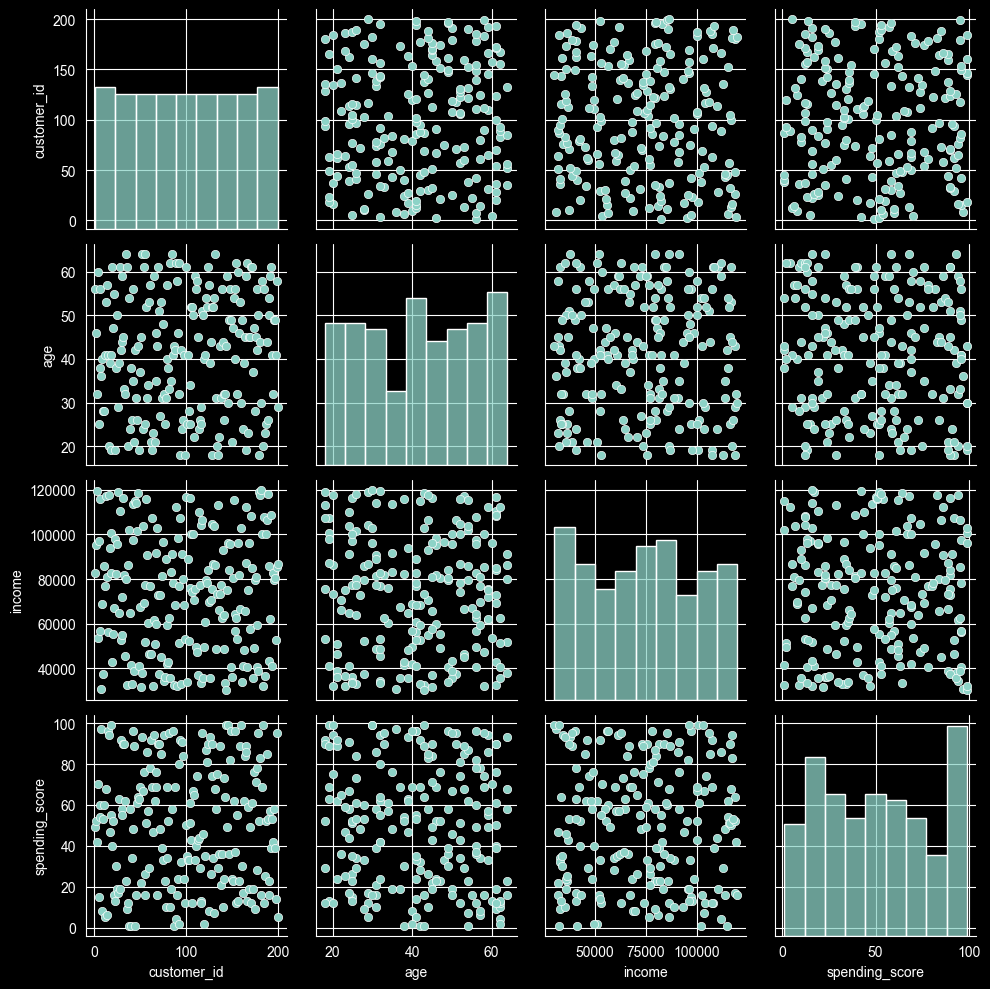

In [33]:
sns.pairplot(df)
plt.tight_layout()
plt.show()

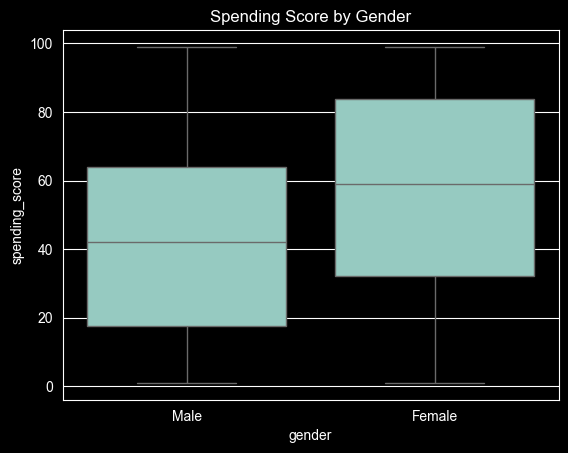

In [36]:
sns.boxplot(
    x="gender",
    y="spending_score",
    data=df
)

plt.title("Spending Score by Gender")

plt.show()

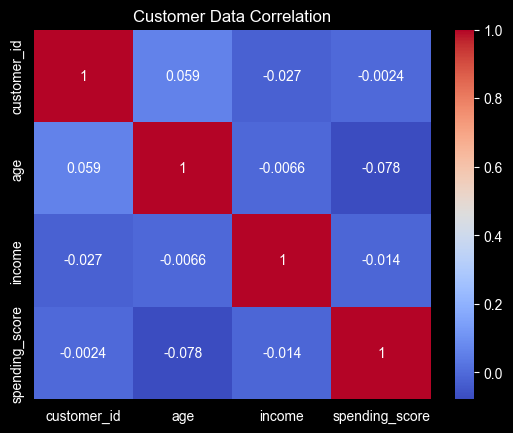

In [37]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Customer Data Correlation")

plt.show()